# Feature Scaling - Normalization

Normalization - technique often used as a part of data preparation for machine learning . 

Goal - change the values of numeric columns in the dataset to use a common scale, without distorting differences in the ranges of values or losing information.

in machine learning literature it is said that it is a good idea to eliminate the units of the numerical columns

Types of the Normalization ->

1}MinMax Scaling(most famous one)(90% of the time we will use only this)

2}Mean normalization

3}Max Absolute scaling

4}Robust Scaling

and many more......

-----
-----

## MinMax Scaling

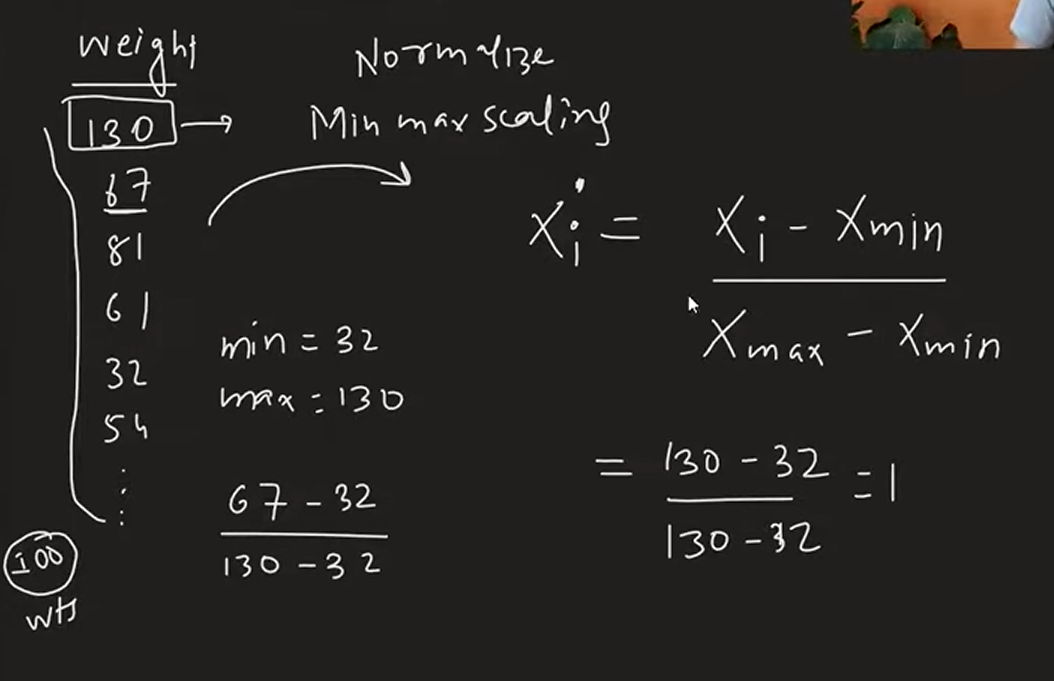

here, we have weight in kg . We do the transformation like Xi' is the scaled value and we will use the stated formula.

Range of the number is always from 0 to 1 in this transformation

Geometric intution:

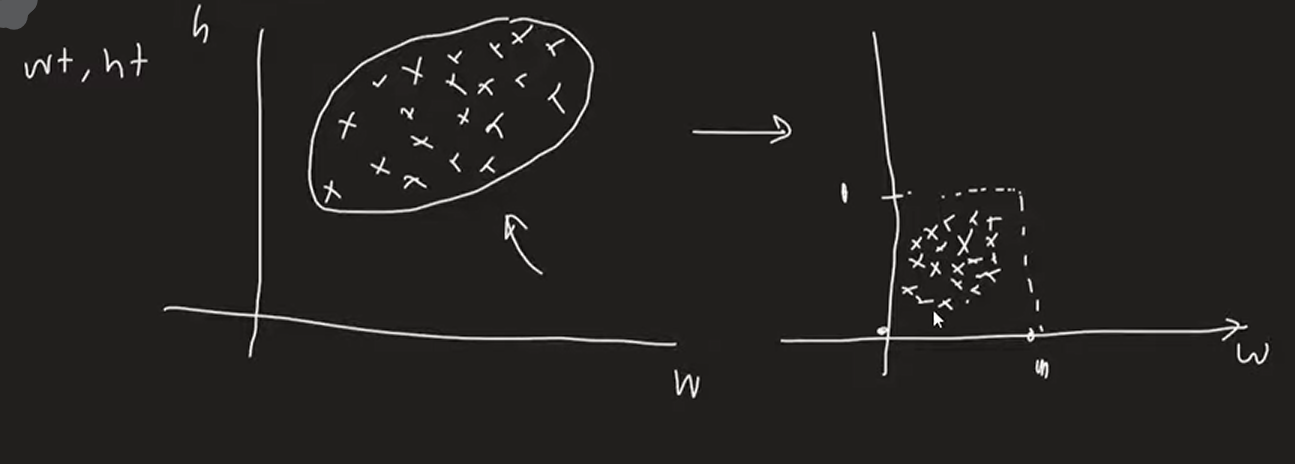

--------------
-------------

Code Example for MinMax Scaling

In [1]:
import numpy as np      #linear algebra
import pandas as pd         #data processing
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df =  pd.read_csv(r'D:/ML/DataSet/wine_data.csv')

In [3]:
df

,1,14.23,1.71,2.43,15.6,127,2.8,3.06,.28,2.29,5.64,1.04,3.92,1065
0,1,13.20,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050
1,1,13.16,2.36,2.67,18.6,101,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185
2,1,14.37,1.95,2.50,16.8,113,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480
3,1,13.24,2.59,2.87,21.0,118,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735
4,1,14.20,1.76,2.45,15.2,112,3.27,3.39,0.34,1.97,6.75,1.05,2.85,1450
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
172,3,13.71,5.65,2.45,20.5,95,1.68,0.61,0.52,1.06,7.70,0.64,1.74,740
173,3,13.40,3.91,2.48,23.0,102,1.80,0.75,0.43,1.41,7.30,0.70,1.56,750
174,3,13.27,4.28,2.26,20.0,120,1.59,0.69,0.43,1.35,10.20,0.59,1.56,835
175,3,13.17,2.59,2.37,20.0,120,1.65,0.68,0.53,1.46,9.30,0.60,1.62,840


In [4]:
df = pd.read_csv(r"D:/ML/DataSet/wine_data.csv" ,header= None,usecols=[0,1,2] )
df.columns = ['Class Label', 'Alcohol' , 'Malic Acid']

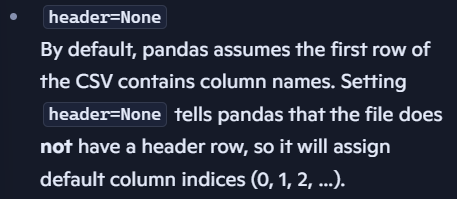

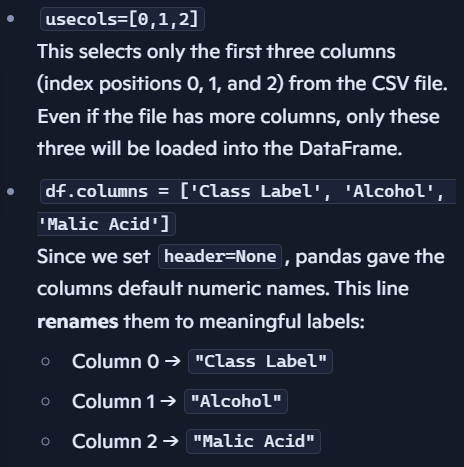

In [5]:
df

,Class Label,Alcohol,Malic Acid
0,1,14.23,1.71
1,1,13.20,1.78
2,1,13.16,2.36
3,1,14.37,1.95
4,1,13.24,2.59
...,...,...,...
173,3,13.71,5.65
174,3,13.40,3.91
175,3,13.27,4.28
176,3,13.17,2.59


<Axes: xlabel='Alcohol', ylabel='Density'>

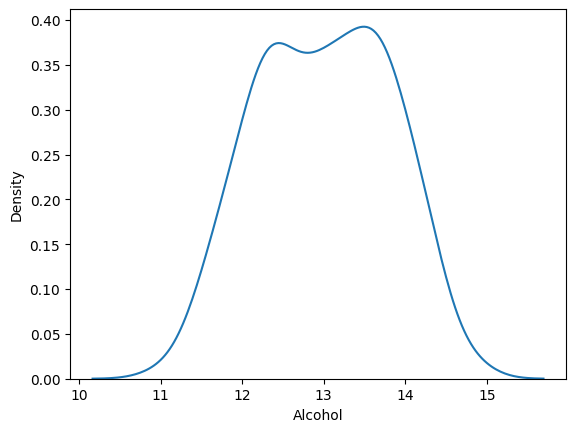

In [6]:
sns.kdeplot(df['Alcohol'])

<Axes: xlabel='Malic Acid', ylabel='Density'>

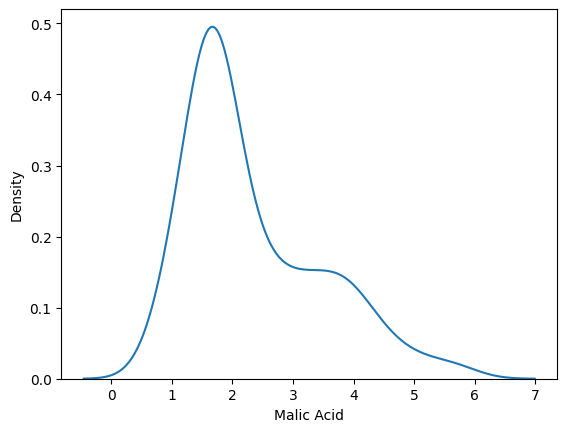

In [7]:
sns.kdeplot(df['Malic Acid'])

<Axes: xlabel='Alcohol', ylabel='Malic Acid'>

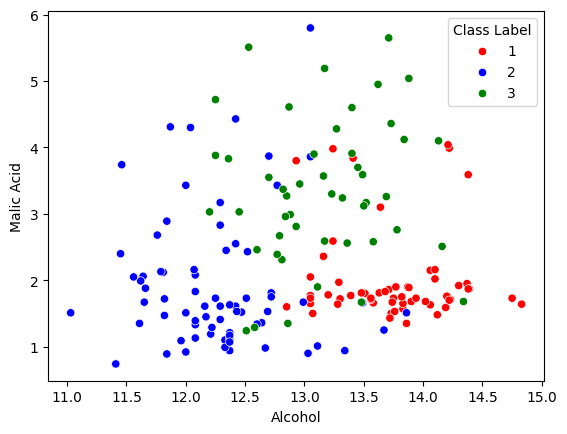

In [15]:
#this will help us to use colors of our need
color_dict={1:'red',3:'green',2:'blue'}
sns.scatterplot(x=df['Alcohol'],y=df['Malic Acid'],hue=df['Class Label'],palette=color_dict)

<Axes: xlabel='Alcohol', ylabel='Malic Acid'>

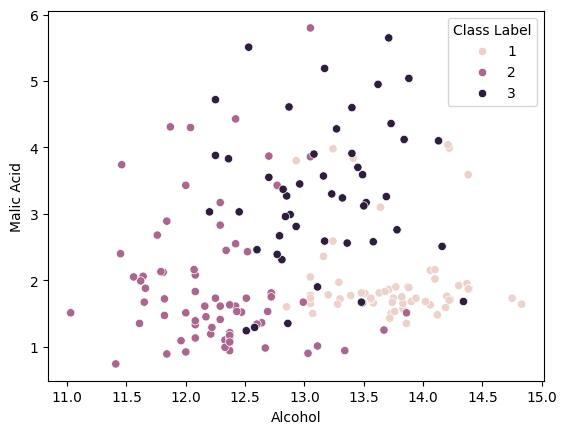

In [16]:
#otherwise the  scatterplot will automatically assign the colors
sns.scatterplot(x=df['Alcohol'],y=df['Malic Acid'],hue=df['Class Label'])

In [17]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(df.drop('Class Label', axis=1),df['Class Label'],test_size=0.3,random_state=0)

X_train.shape, X_test.shape

((124, 2), (54, 2))

In [19]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

# fit the scaler to the train set, it will learn the parameters
scaler.fit(X_train)

# transform train and test sets
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [20]:
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test. columns)

In [21]:
np.round(X_train.describe(),1)

,Alcohol,Malic Acid
count,124.0,124.0
mean,13.0,2.4
std,0.8,1.1
min,11.0,0.9
25%,12.4,1.6
50%,13.0,1.9
75%,13.6,3.2
max,14.8,5.6


In [22]:
np.round(X_train_scaled.describe(),1)

,Alcohol,Malic Acid
count,124.0,124.0
mean,0.5,0.3
std,0.2,0.2
min,0.0,0.0
25%,0.4,0.2
50%,0.5,0.2
75%,0.7,0.5
max,1.0,1.0


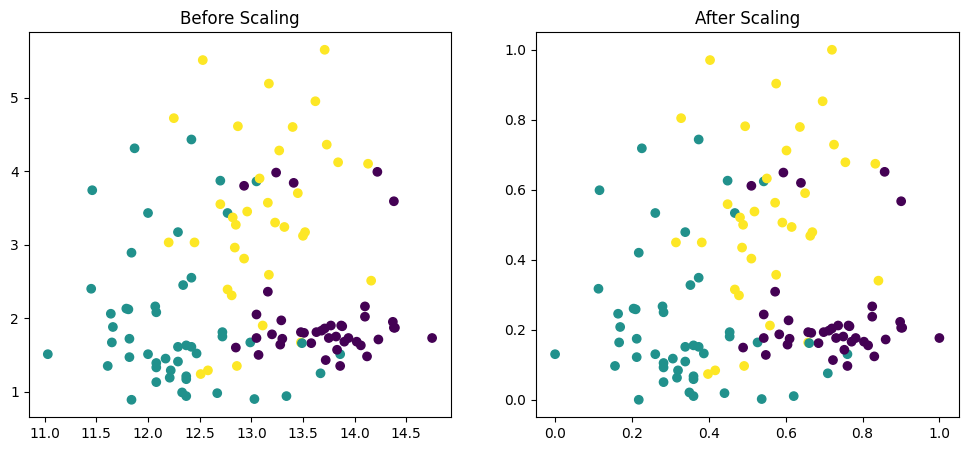

In [24]:
fig, (ax1, ax2)= plt.subplots(ncols=2, figsize=(12, 5))

ax1.scatter(X_train['Alcohol'], X_train['Malic Acid'], c=y_train)
ax1.set_title("Before Scaling")

ax2.scatter(X_train_scaled['Alcohol'], X_train_scaled['Malic Acid'],c=y_train)
ax2.set_title("After Scaling")
plt.show()

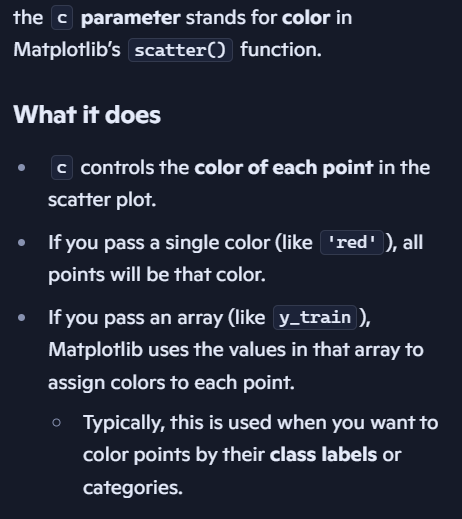

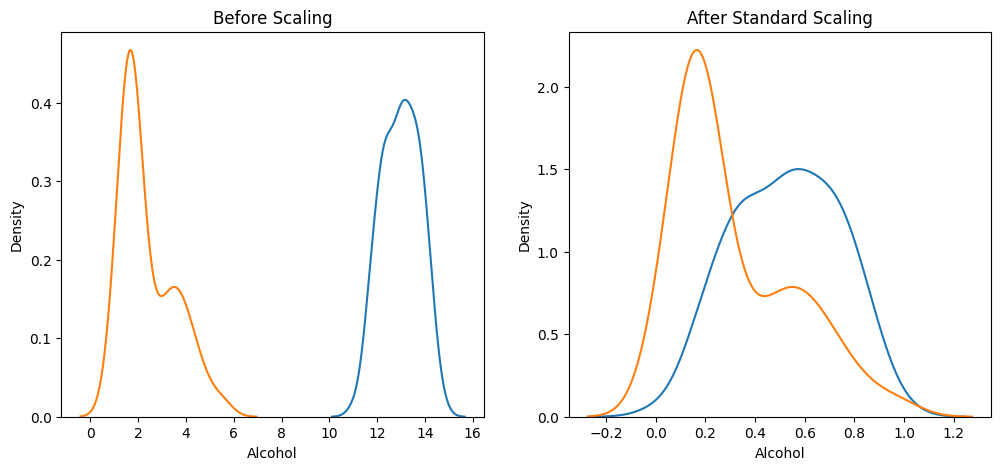

In [26]:
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12, 5))

# before scaling
ax1.set_title('Before Scaling')
sns.kdeplot(X_train['Alcohol'], ax=ax1)
sns.kdeplot(X_train['Malic Acid'], ax=ax1)

# after scaling
ax2.set_title('After Standard Scaling')
sns.kdeplot(X_train_scaled['Alcohol'], ax=ax2)
sns.kdeplot(X_train_scaled['Malic Acid'], ax=ax2)
plt.show()

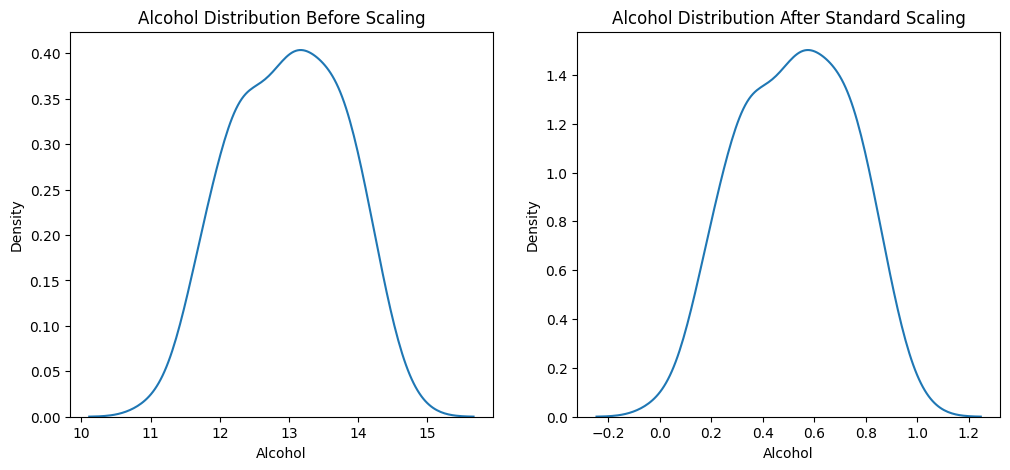

In [27]:
fig, (ax1, ax2)= plt.subplots(ncols=2, figsize=(12, 5))

# before scaling
ax1.set_title('Alcohol Distribution Before Scaling')
sns. kdeplot(X_train['Alcohol'], ax=ax1)

# after scaling
ax2.set_title('Alcohol Distribution After Standard Scaling')
sns. kdeplot(X_train_scaled['Alcohol'], ax=ax2)
plt.show()

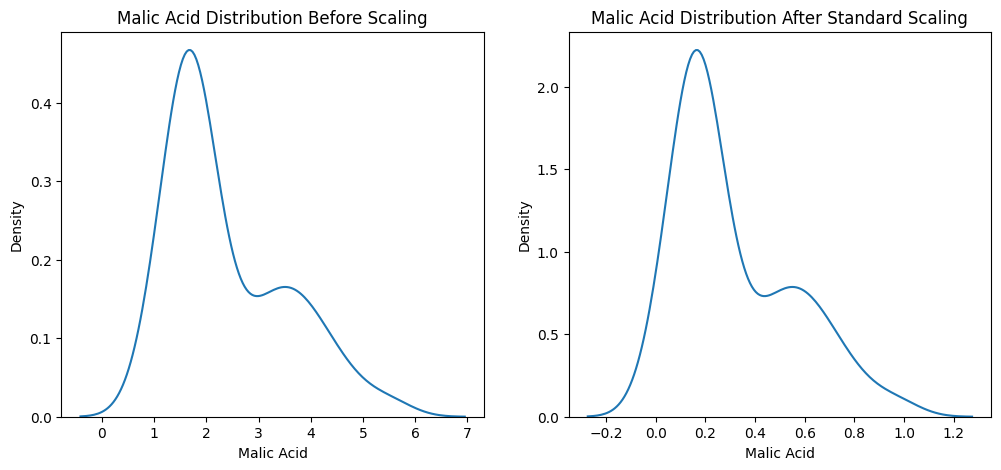

In [28]:
fig, (ax1, ax2)= plt.subplots(ncols=2, figsize=(12, 5))

# before scaling
ax1.set_title('Malic Acid Distribution Before Scaling')
sns. kdeplot(X_train['Malic Acid'], ax=ax1)

# after scaling
ax2.set_title('Malic Acid Distribution After Standard Scaling')
sns. kdeplot(X_train_scaled['Malic Acid'], ax=ax2)
plt.show()

----------------------
--------------------

## Now, we are going to use the other methods for normalization. I am going to paste the pics as this doesnt includes any code

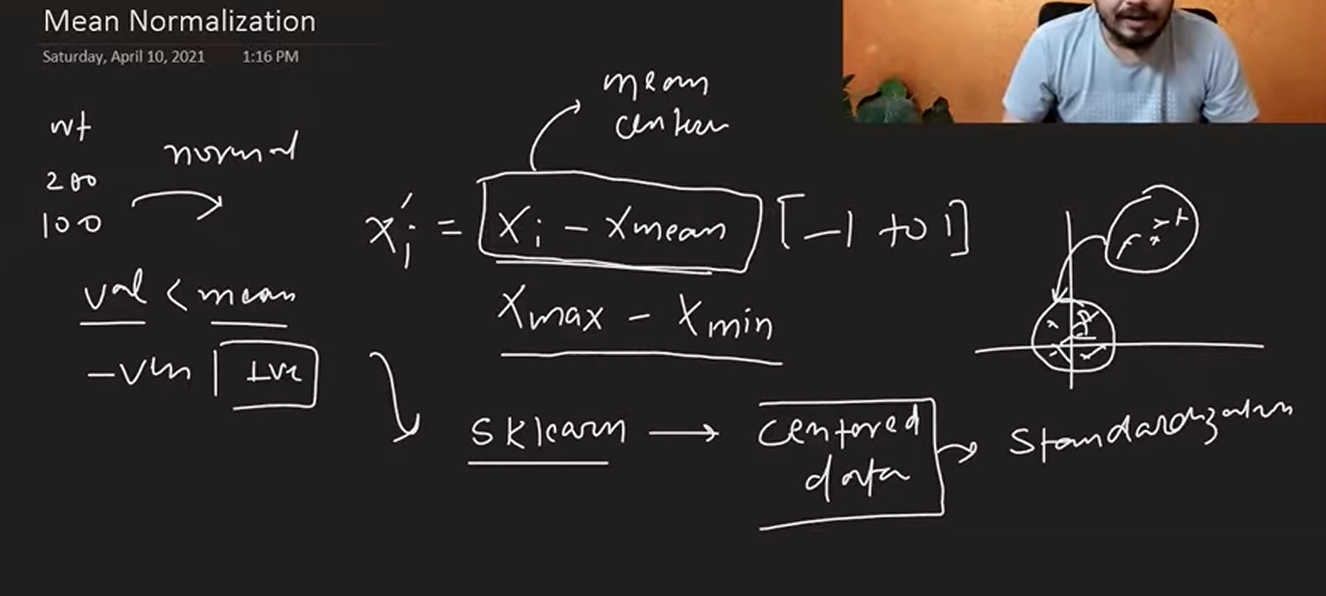

val<mean =>-ve , else +ve

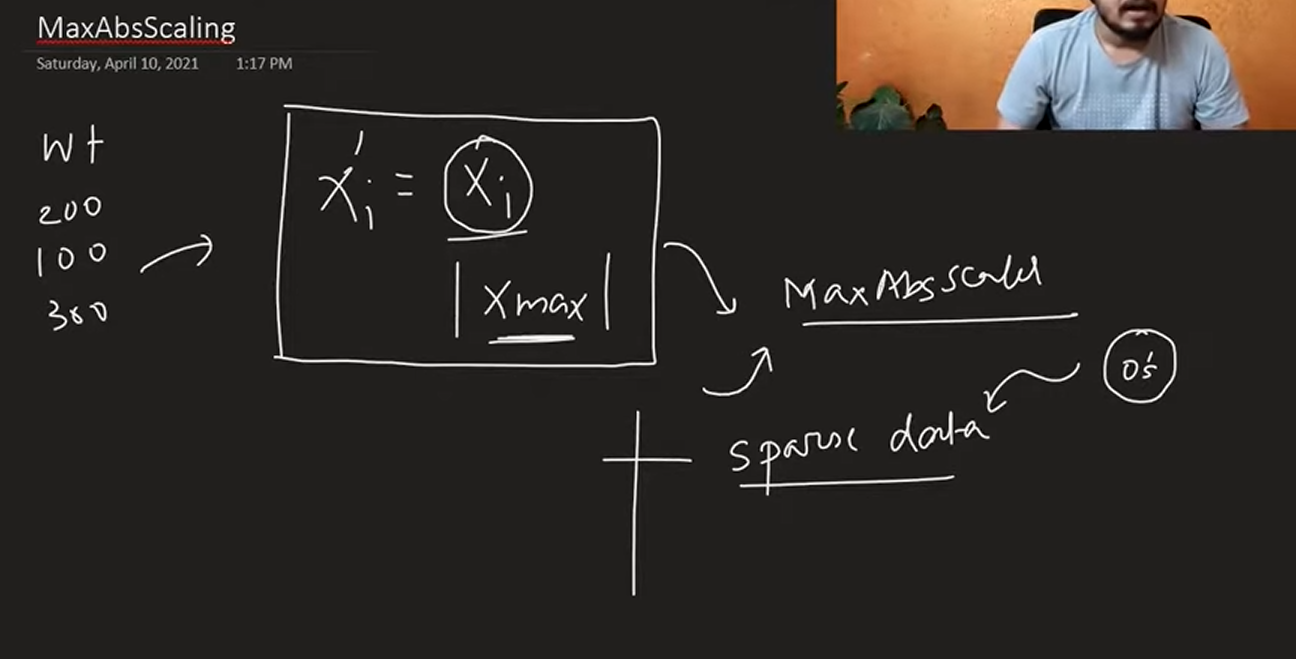

if we have a large no of 0s then we use this.(Large no of 0s = Sparks data)

### Robust Scaling

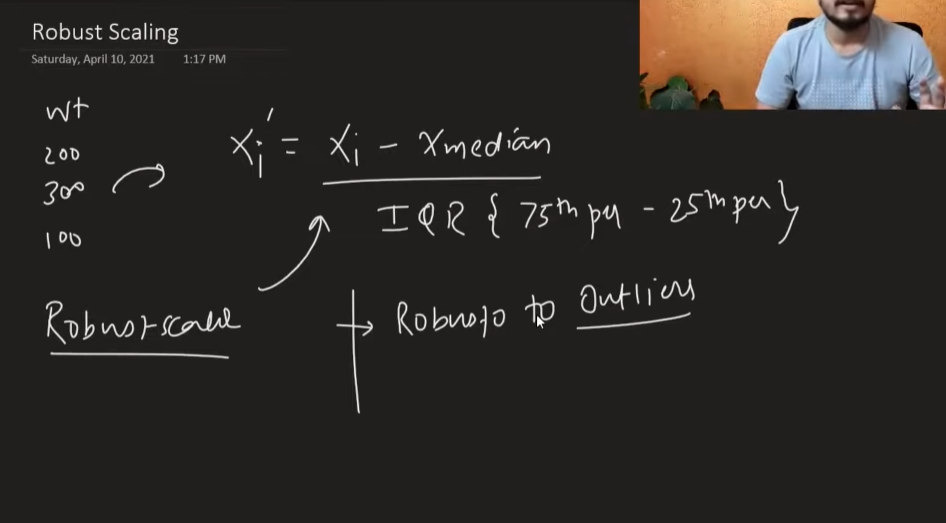

if we have a large no. of outliers then we perform this method

------
------

## Normalization vs Standardization

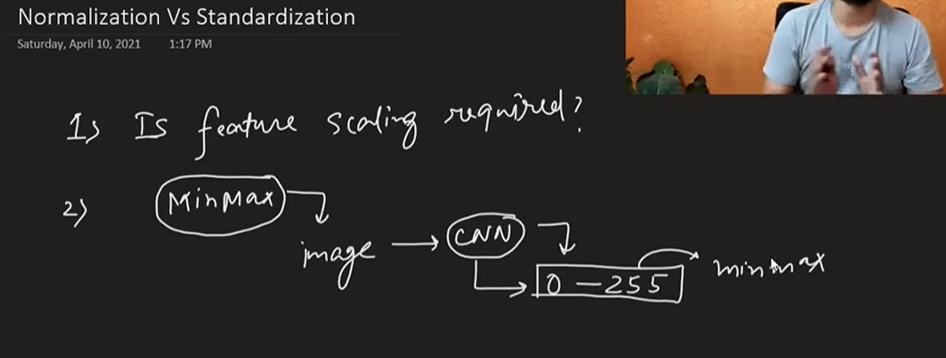